In [1]:
from datetime import date
import pandas as pd
import os
import glob
import pycytominer
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2 

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"

annot_path = parent_directory  + "annotations/"

output_path = parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

# Create Figure for percent matching / percent replication
Way, Gregory P. et al. Morphology and gene expression profiling provide complementary information for mapping cell state

Cell Systems, Volume 13, Issue 11, 911 - 923.e9

For our percent matching metric, we performed a similar procedure as percent replicating (see above). The only differences were that we (1) used level 5 consensus signatures from both data sets and (2) considered MOA and dose information as replicates. We used level 5 consensus signatures instead of level 4 replicate signatures, because consensus signatures are less noisy and correct for potential different replicate cardinalities per compound within an MOA. We only considered MOAs that had three or more annotated compounds. This resulted in an analytical set of 127 unique MOAs. We considered compounds annotated with multiple MOAs as independent entities.


We only considered MOAs that had three or more annotated compounds. 
This resulted in an analytical set of 127 unique MOAs. 
We considered compounds annotated with multiple MOAs as independent entities.

In [4]:
percent_pairing_modality = {
  "FMP_IMTM": 68,
  "FMP_MEDINA": 57.2,
  "FMP_USC": 58.5,
  "IMTM_MEDINA": 54.2,
  "IMTM_USC": 54.8,
  "MEDINA_USC": 63.3
}

In [5]:
percent_matching_modality = {
  "FMP_IMTM": 68.8,
  "FMP_MEDINA": 59.8,
  "FMP_USC": 49.3,
  "IMTM_MEDINA": 49.9,
  "IMTM_USC": 47.9,
  "MEDINA_USC": 58.5
}

In [14]:

# Combine dictionaries into a DataFrame
df = pd.DataFrame({"percent_pairing_modality": percent_pairing_modality, "percent_matching_modality": percent_matching_modality})

In [15]:
df.head()

,percent_pairing_modality,percent_matching_modality
FMP_IMTM,68.0,68.8
FMP_MEDINA,57.2,59.8
FMP_USC,58.5,49.3
IMTM_MEDINA,54.2,49.9
IMTM_USC,54.8,47.9


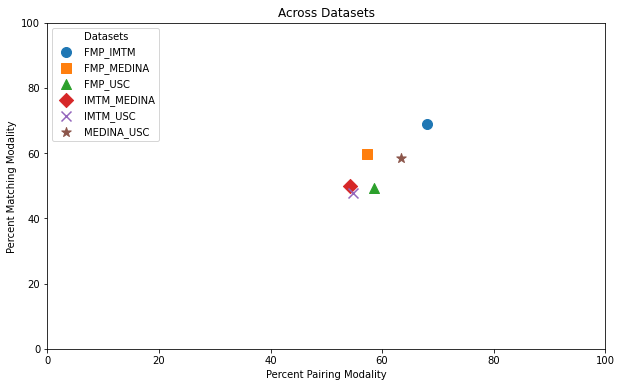

In [31]:
# Different markers for each row
markers = ['o', 's', '^', 'D', 'x', '*'] # Circle, square, triangle, diamond, and cross

# Create the plot
plt.figure(figsize=(10, 6))

for i, row in enumerate(df.index):
    plt.scatter(
        df.loc[row, "percent_pairing_modality"], 
        df.loc[row, "percent_matching_modality"], 
        label=row, 
        marker=markers[i], 
        s=100  # Size of the marker
    )
plt.xlim(0, 100)  
plt.ylim(0, 100) 

# Add labels, legend, and grid
plt.xlabel("Percent Pairing Modality")
plt.ylabel("Percent Matching Modality")
plt.title("Across Datasets")
plt.legend(title="Datasets", loc="upper left")
plt.grid(False)

filename = figure_path + str(date.today()) + "_AcrossDatasets.pdf"

plt.savefig(filename,
            transparent=False,
            bbox_inches='tight',
            dpi = 600)